# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026-2027

### Major Project


## 1. Introduction

This project analyzes agricultural data collected across different seasons,
regions, crops, environmental conditions, resource usage and economic factors.

The main purpose is to identify seasonal patterns, compare agricultural
performance across seasons and derive meaningful data-driven insights.

## 2. Problem Statement

Agricultural performance is influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market conditions.

The objective of this project is to analyze the agricultural dataset and
identify meaningful differences, trends, relationships and variations in
agricultural performance across different seasons.

## 3. Objectives

- Explore and understand the agricultural dataset.
- Clean and prepare the data.
- Analyze agricultural performance across seasons.
- Compare yield, production and profit across seasons.
- Study environmental conditions such as rainfall and temperature.
- Analyze resource usage such as water and fertilizer.
- Investigate relationships between environmental conditions and crop yield.
- Identify important seasonal patterns.
- Perform statistical analysis.
- Provide evidence-based recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")



In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
#random sample of records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [6]:
#check dataset
df.shape

(4000, 28)

In [7]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')

In [8]:
#column names list wise
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [10]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [11]:
#categorical summary
df.describe(include='object')

C:\Users\mypc\AppData\Local\Temp\ipykernel_21868\500806772.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [12]:
# Irrigation Method Distribution

df["Irrigation_Method"].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

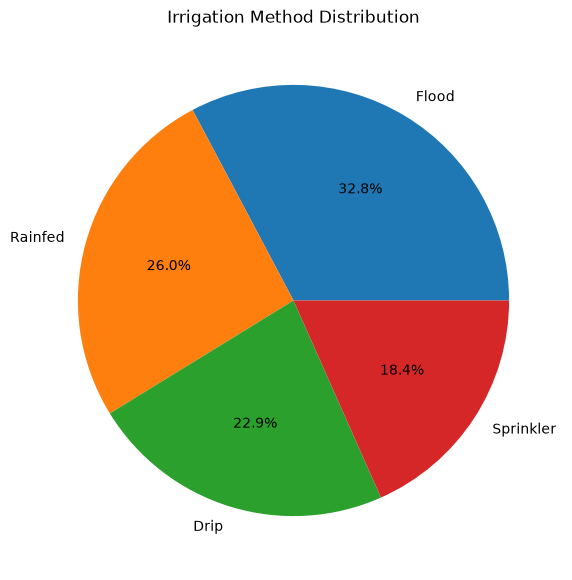

In [13]:
# Pie Chart - Irrigation Method

plt.figure(figsize=(7,7))

df["Irrigation_Method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Irrigation Method Distribution")
plt.ylabel("")

plt.show()

In [14]:
#Checking missing values
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [15]:
#missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage =(df.isnull().mean()* 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "Missing_count": missing,
    "Missing_Percentage": missing_percentage.round(2)

})
missing_summary[missing_summary["Missing_count"] > 0]

,Missing_count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


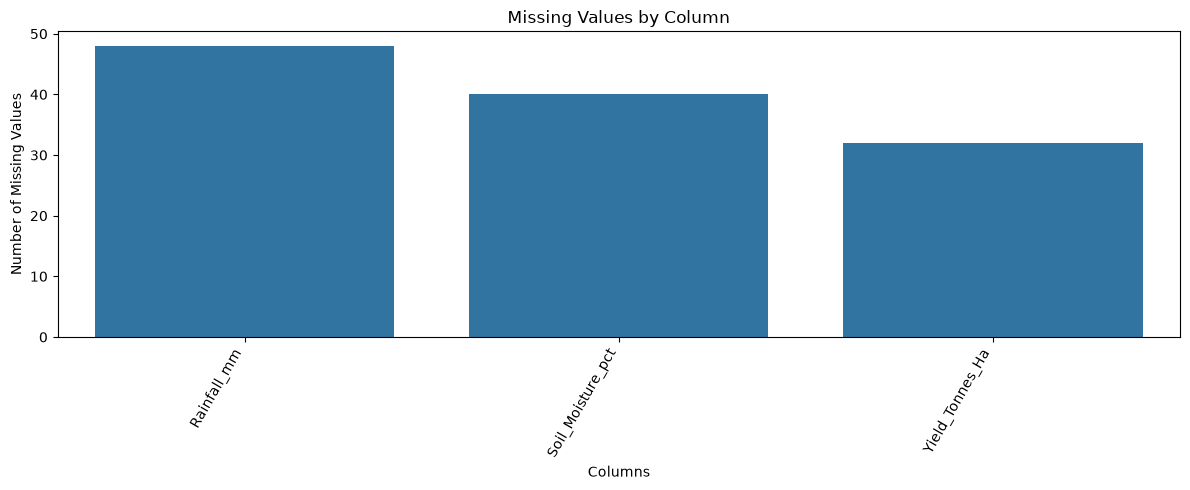

In [16]:
plt.figure(figsize=(12,5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60,ha="right")
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [17]:
#duplicate records
duplicate_records = df.duplicated().sum()
print("Number of duplicate records:", duplicate_records)

Number of duplicate records: 0


In [18]:
#remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [19]:
df.dtypes

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [20]:
#check unique Values for categorical columns
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
<StringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014',
 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']
Length: 20, dtype: str

State:
8 unique values
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District:
10 unique values
<StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop:
8 unique values
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season:
3 unique values
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method:
4 unique values
<StringArray>
['Drip', 'Flood

C:\Users\mypc\AppData\Local\Temp\ipykernel_21868\7780874.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [21]:
#Descriptive statistics
# Descriptive statistics
numeric_columns = df.select_dtypes(include="number").columns
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20,1315.200,464.75000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00,39.000,9.60000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [22]:
#checking seasons
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [23]:
# How does agricultural performance vary across seasons?

df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].mean()

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.643973,46.311192,178914.647555
Rabi,5.080498,41.486712,87689.470191
Zaid,4.665942,38.886111,-24804.824916


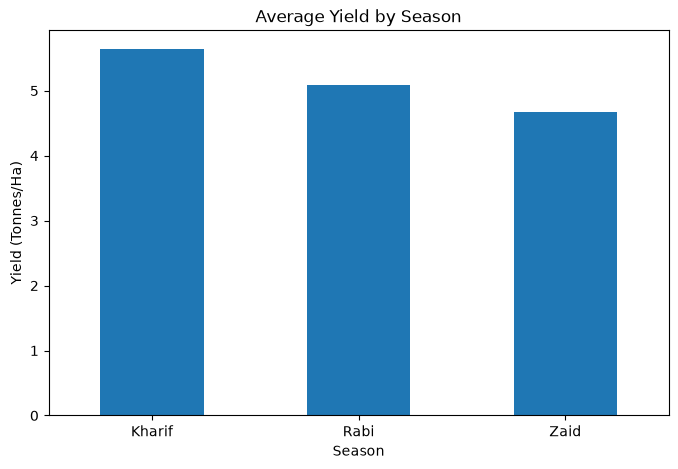

In [24]:
# Bar Plot - Performance by Season

df.groupby("Season")["Yield_Tonnes_Ha"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.show()

In [25]:
#What major seasonal patterns can be observed?
# Seasonal patterns

df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Rainfall_mm"
]].mean()

,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm
Season,,,
Kharif,5.643973,46.311192,852.084205
Rabi,5.080498,41.486712,436.000124
Zaid,4.665942,38.886111,299.421784


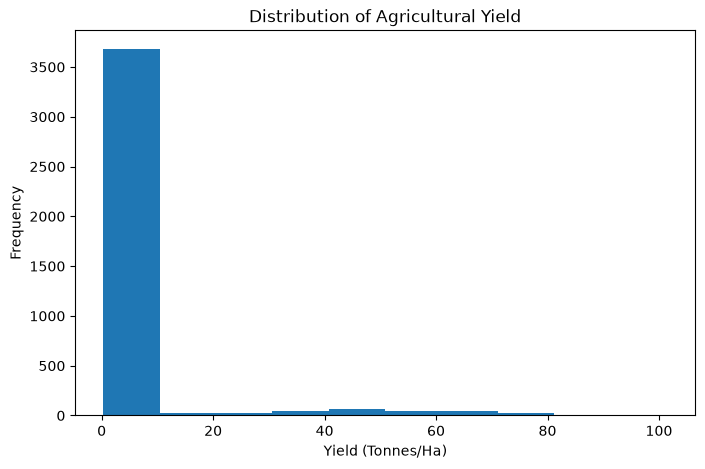

In [26]:
# Histogram - Yield Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Yield_Tonnes_Ha"], bins=10)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.show()

In [27]:
#Which characteristics change between seasons?
# Characteristics by season

df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct"
]].mean()

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct
Season,,,
Kharif,852.084205,28.454019,31.198410
Rabi,436.000124,23.489183,24.050620
Zaid,299.421784,31.042088,19.170085


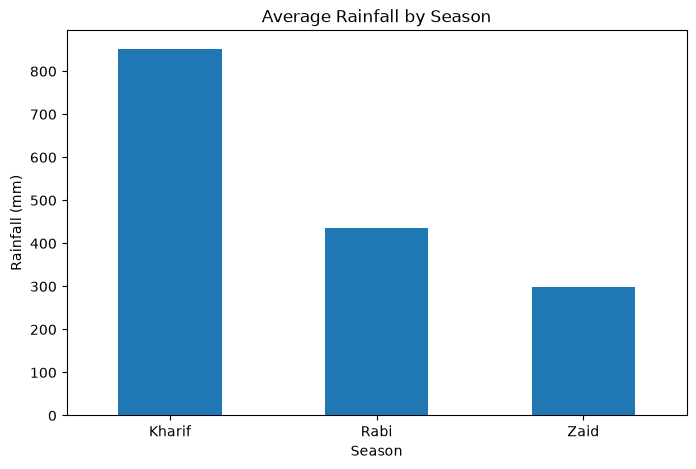

In [28]:
# Bar Plot - Rainfall by Season

df.groupby("Season")["Rainfall_mm"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)

plt.show()

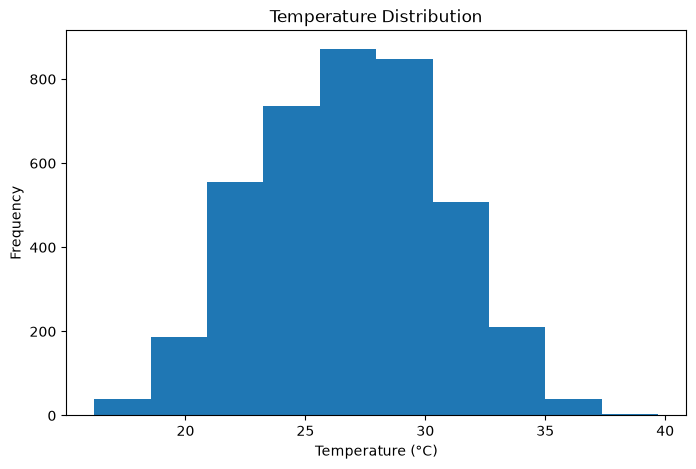

In [29]:
# Histogram - Temperature
# bins = number of intervals

plt.figure(figsize=(8,5))

plt.hist(df["Avg_Temperature_C"], bins=10)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

In [30]:
#What differences exist between agricultural activities in different seasons?
# Crop performance in different seasons

df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"].mean()

Season  Crop     
Kharif  Chilli        1.731413
        Cotton        1.372804
        Groundnut     1.483646
        Maize         2.966410
        Pulses        1.036063
        Rice          2.707621
        Sugarcane    53.459120
        Wheat         2.255430
Rabi    Chilli        1.461615
        Cotton        1.192915
        Groundnut     1.221445
        Maize         2.614913
        Pulses        0.871887
        Rice          2.333680
        Sugarcane    43.940394
        Wheat         2.058814
Zaid    Chilli        1.177742
        Cotton        0.951648
        Groundnut     1.037778
        Maize         2.297590
        Pulses        0.652131
        Rice          1.900490
        Sugarcane    38.423922
        Wheat         1.748588
Name: Yield_Tonnes_Ha, dtype: float64

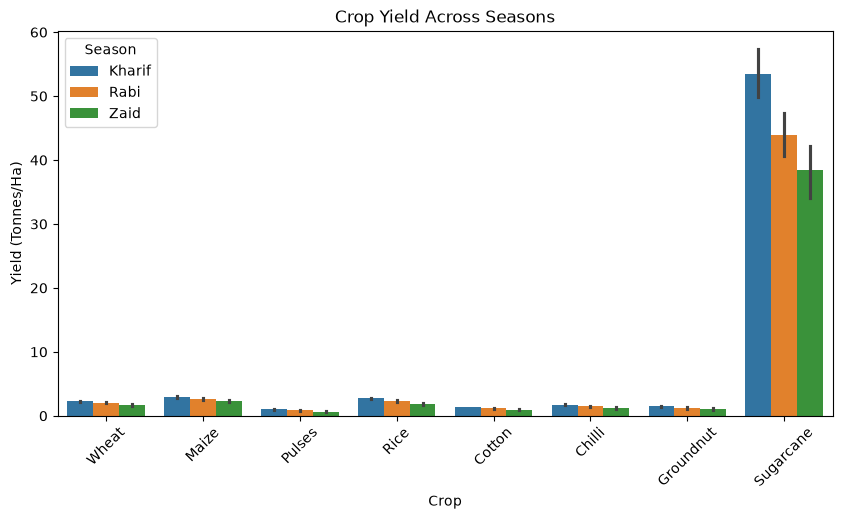

In [31]:
# Bar Plot - Crop Yield by Season

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

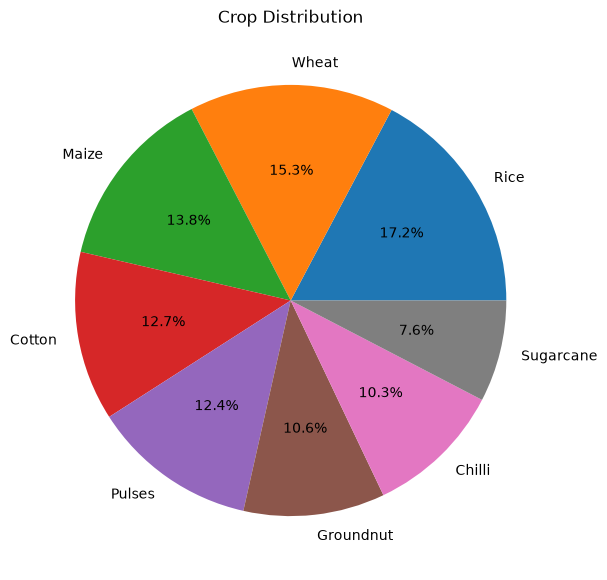

In [32]:
# Pie Chart - Crop Distribution

crop_count = df["Crop"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    crop_count,
    labels=crop_count.index,
    autopct="%1.1f%%"
)

plt.title("Crop Distribution")

plt.show()

In [33]:
#Are there noticeable variations in resource usage across seasons?
# Resource usage by season

df.groupby("Season")[[
    "Water_Used_m3",
    "Fertilizer_kg_ha"
]].mean()

,Water_Used_m3,Fertilizer_kg_ha
Season,,
Kharif,6102.201237,187.077965
Rabi,5846.987093,185.407068
Zaid,6419.893939,184.638047


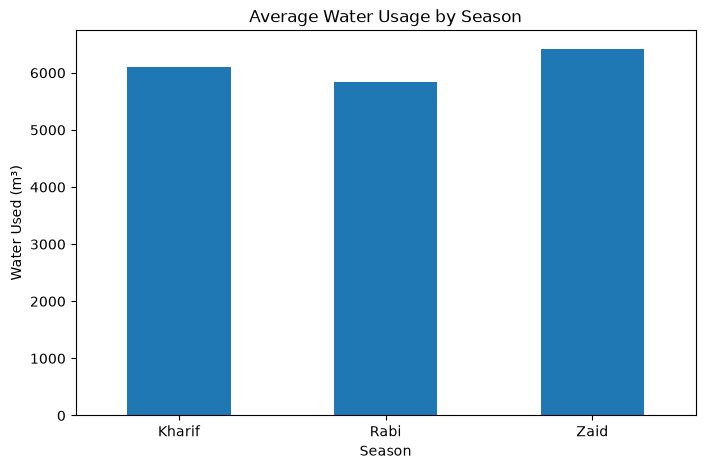

In [34]:
# Bar Plot - Water Usage

df.groupby("Season")["Water_Used_m3"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)

plt.show()

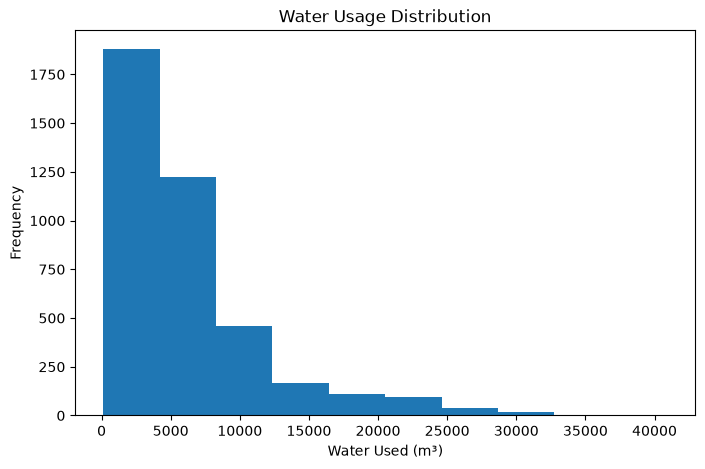

In [35]:
# Histogram - Water Usage

plt.figure(figsize=(8,5))

plt.hist(df["Water_Used_m3"], bins=10)

plt.title("Water Usage Distribution")
plt.xlabel("Water Used (m³)")
plt.ylabel("Frequency")

plt.show()

In [36]:
# Water Efficiency by Season

df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().round(2)

Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64

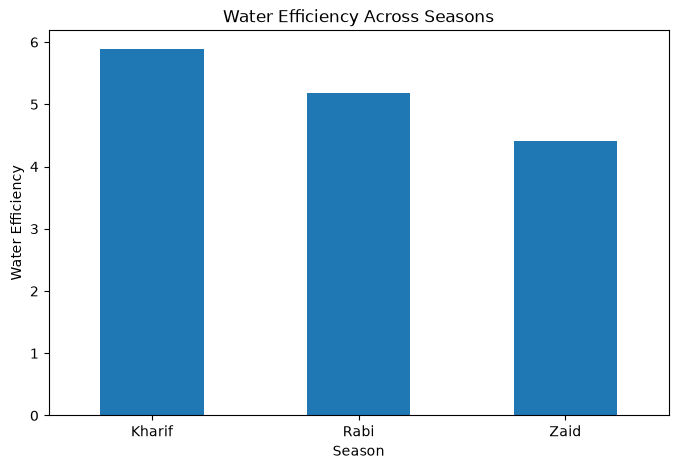

In [37]:
# Bar Plot - Water Efficiency by Season

df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.xticks(rotation=0)

plt.show()

In [38]:
#Are there relationships between seasonal environmental conditions and agricultural performance?
# Correlation between environment and yield

df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]].corr()

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.200020,0.515751,0.030853
Avg_Temperature_C,0.200020,1.000000,0.084492,0.009349
Soil_Moisture_pct,0.515751,0.084492,1.000000,0.010210
Yield_Tonnes_Ha,0.030853,0.009349,0.010210,1.000000


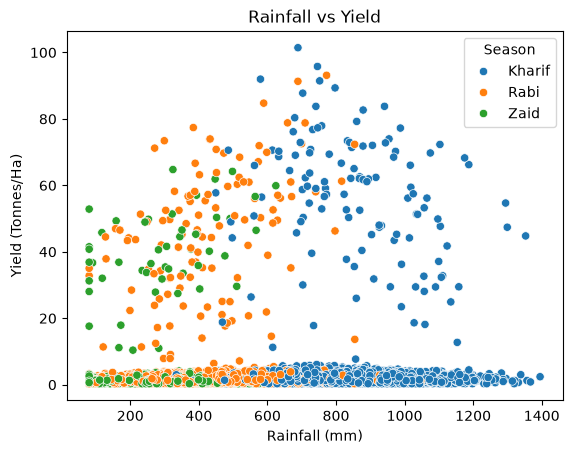

In [39]:
# Rainfall vs Yield
#scatter plot
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

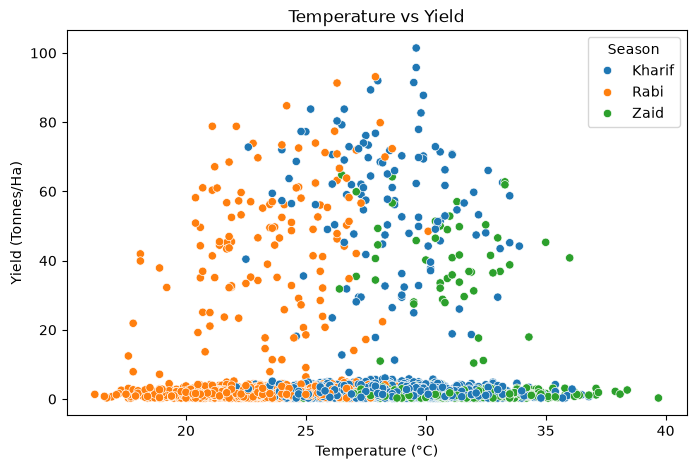

In [40]:
# Temperature vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

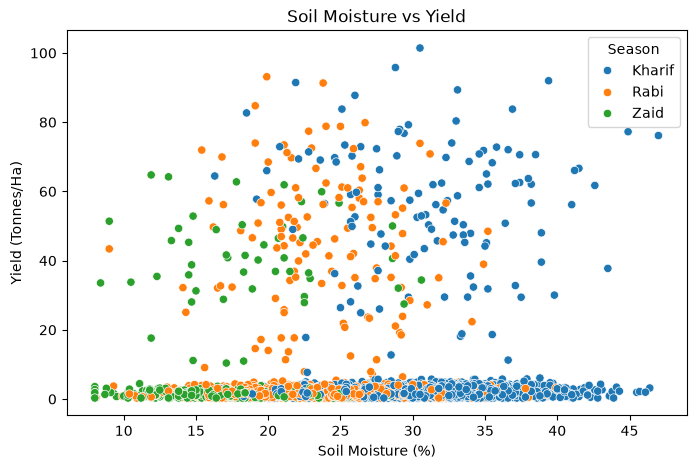

In [41]:
# Soil Moisture vs Yield

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Soil Moisture vs Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [42]:
#How do economic outcomes vary across seasons?
# Economic performance by season

df.groupby("Season")[[
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].mean()

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


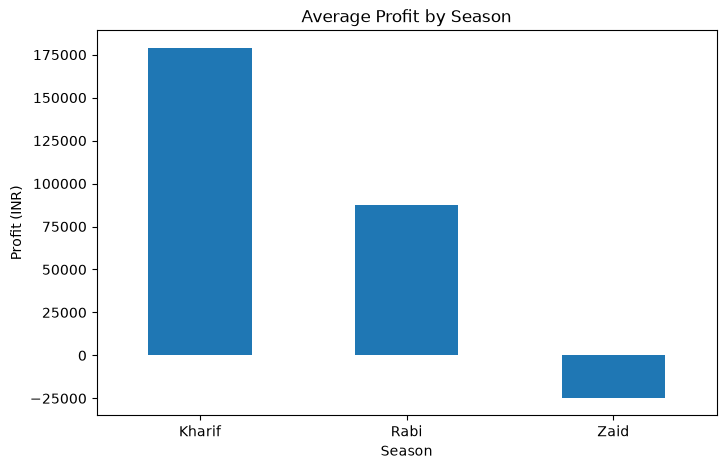

In [43]:
# Bar Plot - Profit by Season

df.groupby("Season")["Profit_INR"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=0)

plt.show()

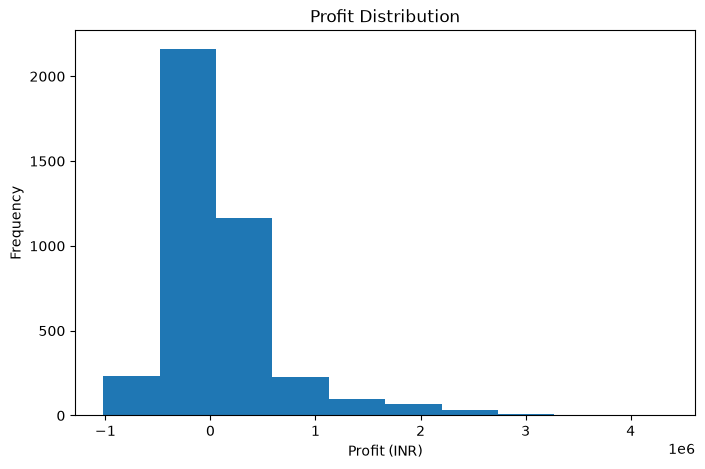

In [44]:
# Histogram - Profit Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Profit_INR"], bins=10)

plt.title("Profit Distribution")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.show()

In [45]:
# Cost, Revenue and Profit by Season

economic_summary = df.groupby("Season")[[
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].mean()

economic_summary.round(2)

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


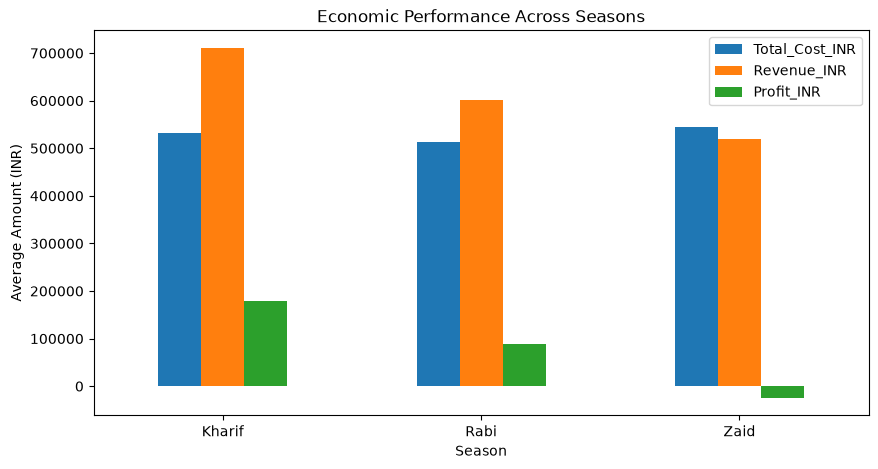

In [46]:
# Bar Plot - Economic Performance

economic_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)

plt.show()

In [47]:
#Are some seasonal patterns consistent across different regions or categories?

# Yield by State and Season

df.groupby(
    ["State", "Season"]
)["Yield_Tonnes_Ha"].mean()


State           Season
Andhra Pradesh  Kharif    5.693431
                Rabi      3.488069
                Zaid      4.480238
Gujarat         Kharif    6.338416
                Rabi      5.517245
                Zaid      4.101970
Karnataka       Kharif    6.523689
                Rabi      4.609655
                Zaid      6.623243
Madhya Pradesh  Kharif    6.004133
                Rabi      3.800000
                Zaid      5.539194
Maharashtra     Kharif    5.447014
                Rabi      5.501927
                Zaid      2.285352
Punjab          Kharif    4.100633
                Rabi      8.609355
                Zaid      5.909610
Tamil Nadu      Kharif    5.520534
                Rabi      4.555539
                Zaid      4.097746
Telangana       Kharif    5.568798
                Rabi      4.831649
                Zaid      4.278333
Name: Yield_Tonnes_Ha, dtype: float64

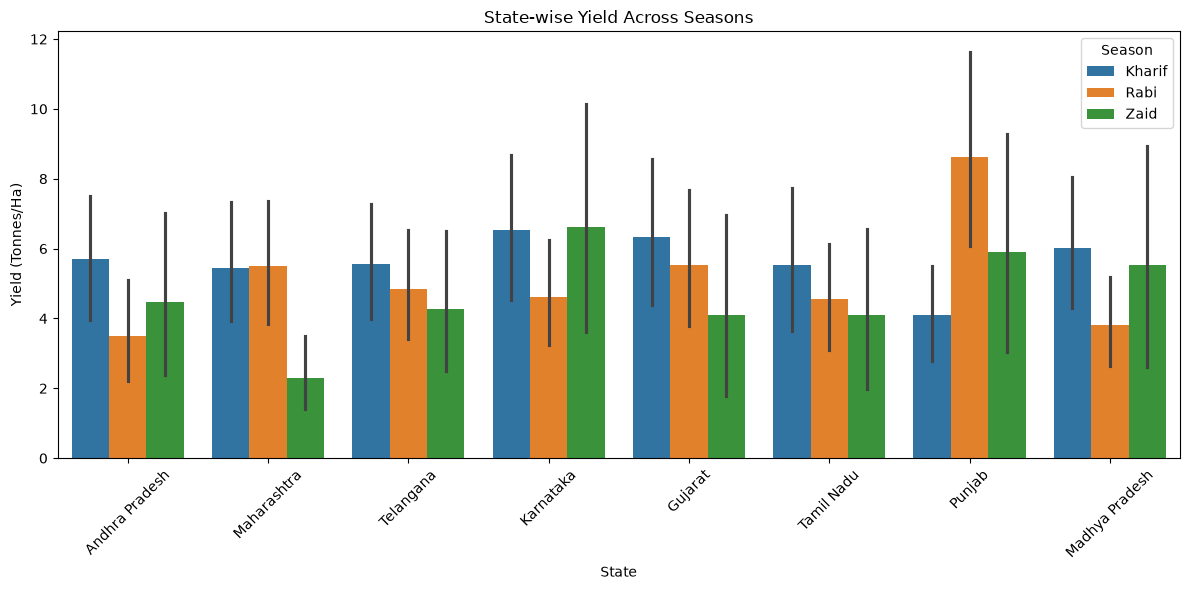

In [48]:
# State-wise seasonal yield

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="State",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("State-wise Yield Across Seasons")
plt.xlabel("State")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
# Yield by District and Season

df.groupby(
    ["District", "Season"]
)["Yield_Tonnes_Ha"].mean()

District  Season
Erode     Kharif    4.326461
          Rabi      4.480728
          Zaid      3.308116
Guntur    Kharif    6.024056
          Rabi      4.580066
          Zaid      6.305000
Indore    Kharif    6.120820
          Rabi      3.535779
          Zaid      4.538364
Krishna   Kharif    5.507760
          Rabi      4.755541
          Zaid      2.906800
Ludhiana  Kharif    6.406864
          Rabi      5.618333
          Zaid      5.075821
Nalgonda  Kharif    6.582151
          Rabi      4.468286
          Zaid      7.510615
Nashik    Kharif    5.553193
          Rabi      4.716389
          Zaid      3.390339
Raichur   Kharif    4.119886
          Rabi      6.737310
          Zaid      3.287705
Rajkot    Kharif    6.686220
          Rabi      5.963889
          Zaid      4.326786
Warangal  Kharif    5.269356
          Rabi      5.783659
          Zaid      5.898039
Name: Yield_Tonnes_Ha, dtype: float64

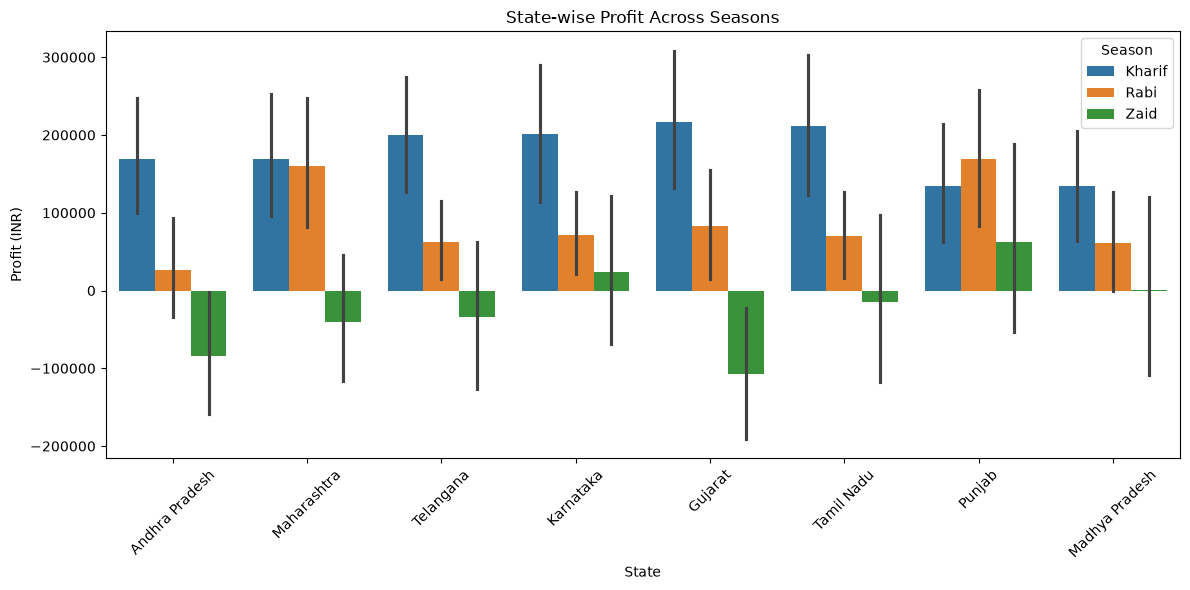

In [50]:
# State-wise Profit Across Seasons

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="State",
    y="Profit_INR",
    hue="Season"
)

plt.title("State-wise Profit Across Seasons")
plt.xlabel("State")
plt.ylabel("Profit (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
#outlier section
#Are there unusual or unexpected seasonal patterns?
# Minimum, maximum and average values

df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].agg(["min", "max", "mean"]).round(2)

Yield_Tonnes_Ha               Production_Tonnes                  \
                   min     max  mean               min      max   mean   
Season                                                                   
Kharif             0.3  101.44  5.64              0.20  1424.40  46.31   
Rabi               0.3   93.13  5.08              0.19  1249.21  41.49   
Zaid               0.3   64.76  4.67              0.15   956.73  38.89   

       Profit_INR                      
              min      max       mean  
Season                                 
Kharif    -976860  4345421  178914.65  
Rabi     -1019223  3378879   87689.47  
Zaid      -965197  2349990  -24804.82

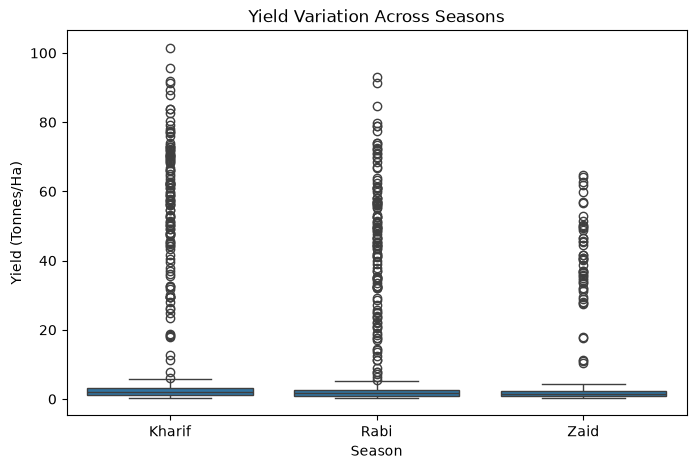

In [52]:
# Box Plot - Detect unusual yield values

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

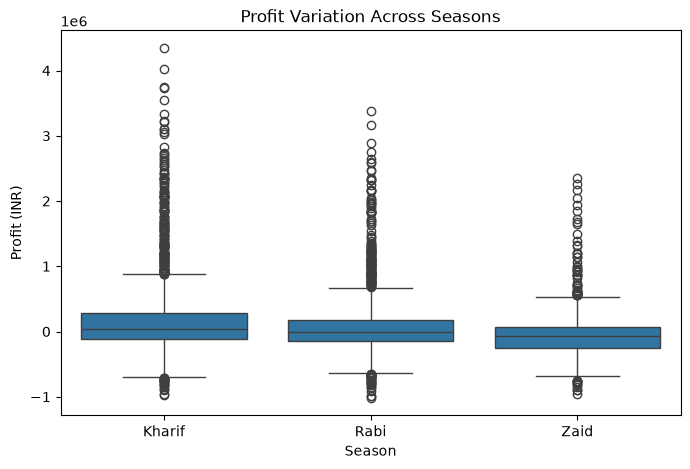

In [53]:
# Box Plot - Profit Variation

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

In [54]:
#What insights can be derived from the observed seasonal differences?
# Seasonal summary

summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Water_Used_m3"
]].mean()

summary.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Rainfall_mm,Water_Used_m3
Season,,,,,
Kharif,5.64,46.31,178914.65,852.08,6102.20
Rabi,5.08,41.49,87689.47,436.00,5846.99
Zaid,4.67,38.89,-24804.82,299.42,6419.89


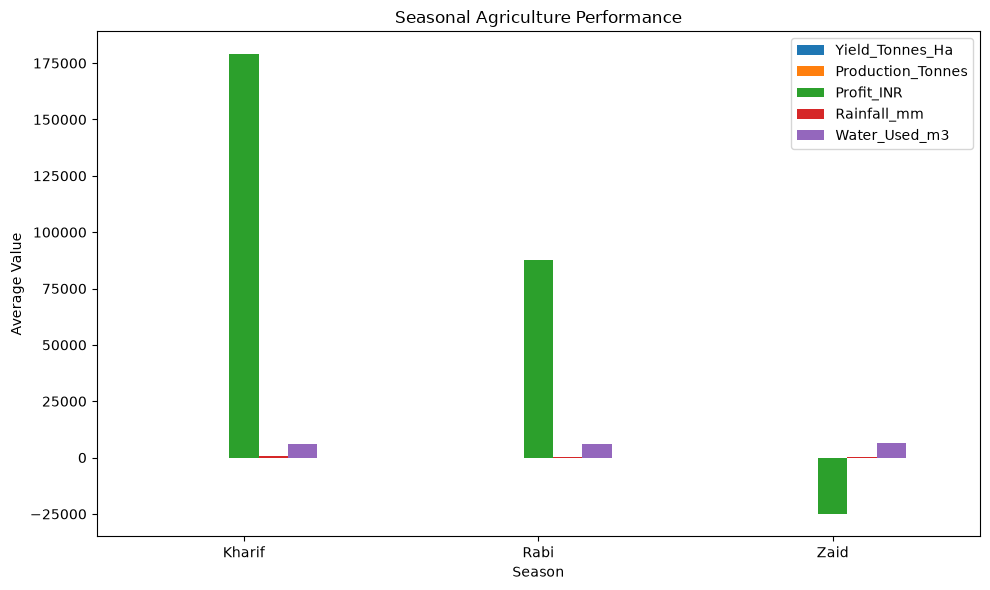

In [55]:
# Compare Seasonal Performance

summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Seasonal Agriculture Performance")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [56]:
# Best Season Based on Yield

best_yield_season = summary["Yield_Tonnes_Ha"].idxmax()

print("Best season based on average yield:", best_yield_season)

Best season based on average yield: Kharif


In [57]:
# Best Season Based on Profit

best_profit_season = summary["Profit_INR"].idxmax()

print("Best season based on average profit:", best_profit_season)

Best season based on average profit: Kharif


In [58]:
#What conclusions can reasonably be drawn from the available data?
# Conclusion based on seasonal performance

season_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].mean()

print("Seasonal Performance Summary:")
print(season_summary.round(2))

best_yield = season_summary["Yield_Tonnes_Ha"].idxmax()
best_production = season_summary["Production_Tonnes"].idxmax()
best_profit = season_summary["Profit_INR"].idxmax()

print("\nConclusion:")
print("Highest average yield:", best_yield)
print("Highest average production:", best_production)
print("Highest average profit:", best_profit)

Seasonal Performance Summary:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.64              46.31   178914.65
Rabi               5.08              41.49    87689.47
Zaid               4.67              38.89   -24804.82

Conclusion:
Highest average yield: Kharif
Highest average production: Kharif
Highest average profit: Kharif


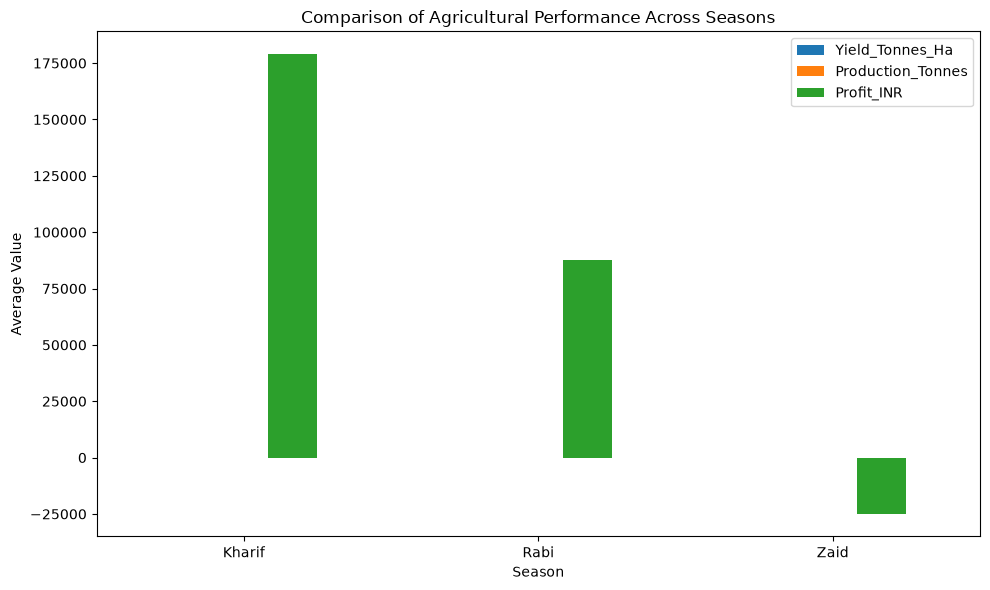

In [59]:
# Compare all seasons

season_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [60]:
#How could the findings support better seasonal agricultural planning?
# Seasonal Agricultural Planning Recommendations

print("Seasonal Agricultural Planning Recommendations")
print("----------------------------------------------")

print("1. Select crops according to seasonal conditions.")
print("2. Plan irrigation based on rainfall and water requirements.")
print("3. Monitor temperature and soil moisture.")
print("4. Use fertilizer according to crop and soil requirements.")
print("5. Choose seasons with better yield and production.")
print("6. Consider profit and production costs during planning.")
print("7. Use seasonal data to improve resource management.")

Seasonal Agricultural Planning Recommendations
----------------------------------------------
1. Select crops according to seasonal conditions.
2. Plan irrigation based on rainfall and water requirements.
3. Monitor temperature and soil moisture.
4. Use fertilizer according to crop and soil requirements.
5. Choose seasons with better yield and production.
6. Consider profit and production costs during planning.
7. Use seasonal data to improve resource management.


In [61]:
#1. UNIVARIATE ANALYSIS

#Univariate analysis means analyzing one variable at a time.

#1.1 Season Distribution
# ============================================================
# UNIVARIATE ANALYSIS
# Season Distribution
# ============================================================

df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

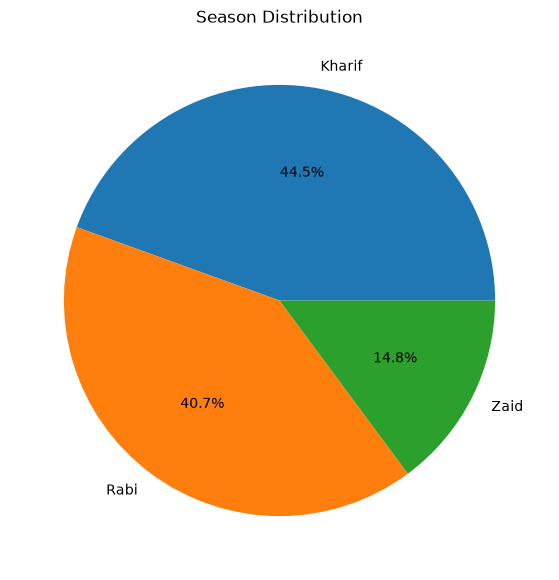

In [62]:
plt.figure(figsize=(7,7))

df["Season"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Season Distribution")
plt.ylabel("")

plt.show()

In [63]:
# Yield distribution

df["Yield_Tonnes_Ha"].describe()

count    3968.000000
mean        5.270595
std        13.361398
min         0.300000
25%         1.050000
50%         1.740000
75%         2.840000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64

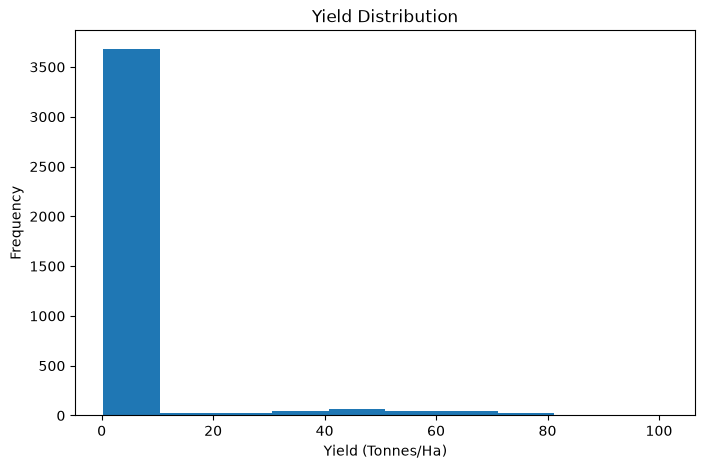

In [64]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Yield_Tonnes_Ha"],
    bins=10
)

plt.title("Yield Distribution")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.show()

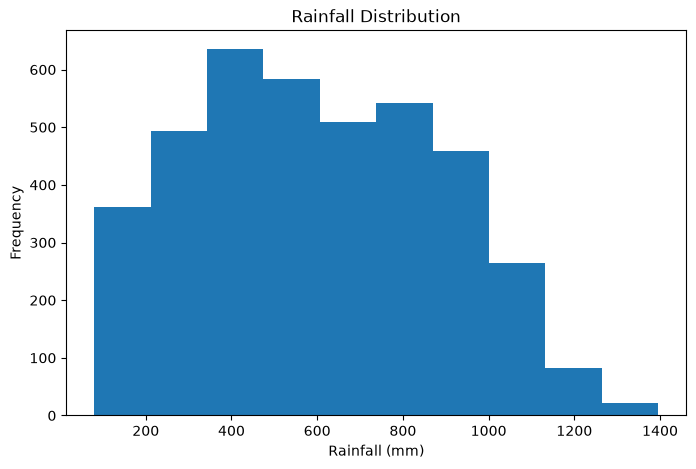

In [65]:
# Rainfall distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Rainfall_mm"],
    bins=10
)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

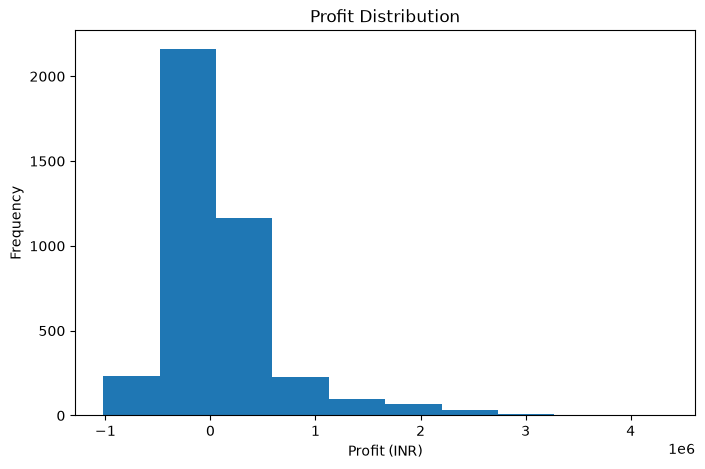

In [66]:
# Profit distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Profit_INR"],
    bins=10
)

plt.title("Profit Distribution")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.show()

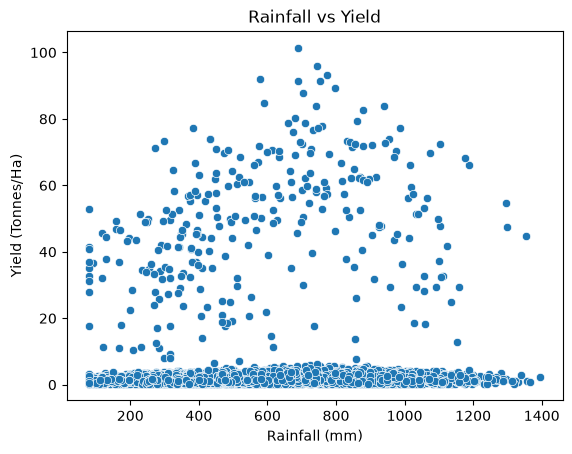

In [67]:
#2. BIVARIATE ANALYSIS

#Bivariate analysis means analyzing the relationship between two variables.

#2.1 Rainfall vs Yield
# ============================================================
# BIVARIATE ANALYSIS
# Rainfall vs Yield
# ============================================================

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha"
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

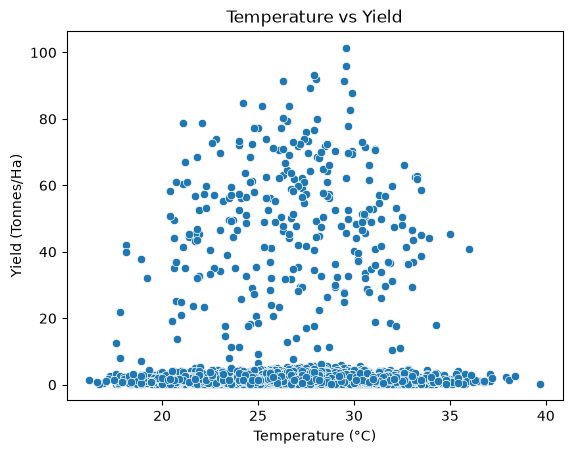

In [68]:
#2.2 Temperature vs Yield
sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha"
)

plt.title("Temperature vs Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

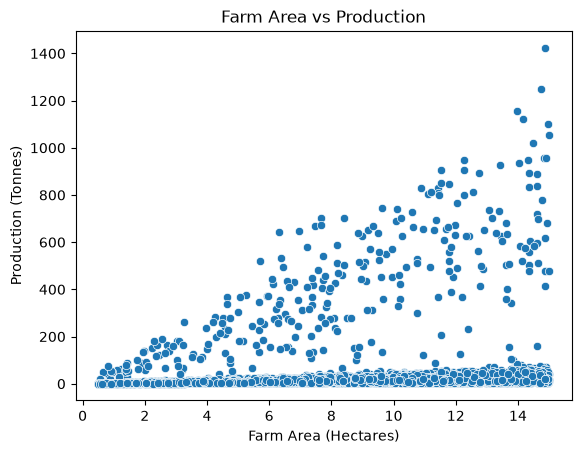

In [69]:
#2.3 Farm Area vs Production
sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes"
)

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.show()

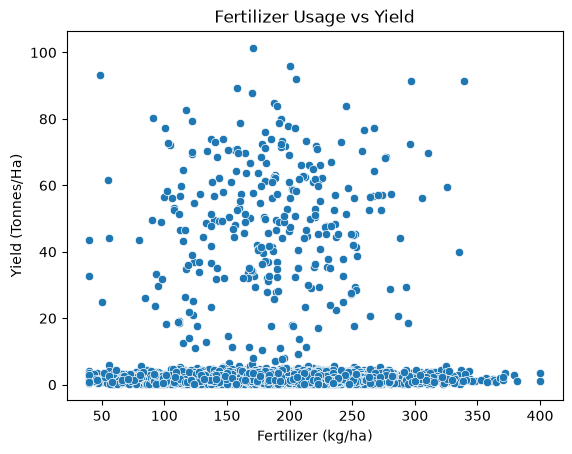

In [70]:
#2.4 Fertilizer vs Yield
sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha"
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

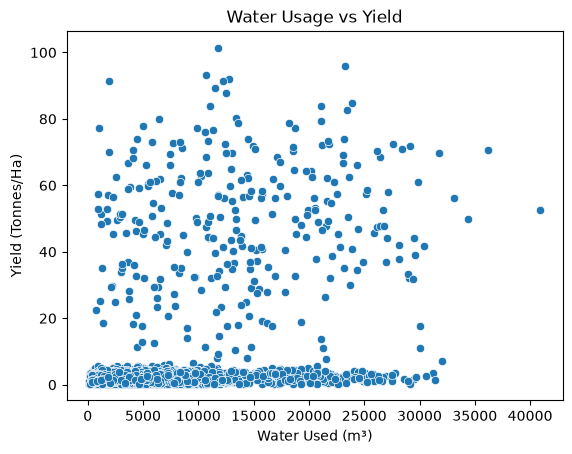

In [71]:
#2.5 Water Usage vs Yield
sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha"
)

plt.title("Water Usage vs Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

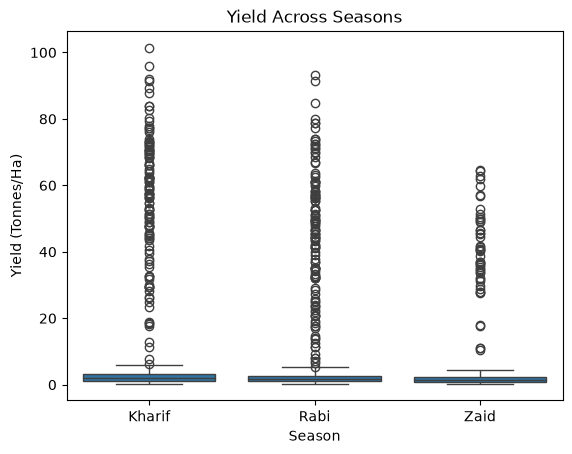

In [72]:
#2.6 Season vs Yield
sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [73]:
#3. MULTIVARIATE ANALYSIS

#Multivariate analysis means studying three or more variables together.

#3.1 Correlation Analysis
# ============================================================
# MULTIVARIATE ANALYSIS
# Correlation
# ============================================================

correlation = df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].corr()

correlation


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Rainfall_mm,1.000000,0.200020,0.523966,0.515751,0.024610,0.002324,0.030853,0.024551,0.108104
Avg_Temperature_C,0.200020,1.000000,0.138136,0.084492,0.015861,0.022995,0.009349,0.007346,0.009043
Humidity_pct,0.523966,0.138136,1.000000,0.448717,0.024623,-0.002086,0.011277,0.003614,0.063775
Soil_Moisture_pct,0.515751,0.084492,0.448717,1.000000,0.008836,0.003276,0.010210,0.004848,0.091757
Fertilizer_kg_ha,0.024610,0.015861,0.024623,0.008836,1.000000,0.000895,0.000562,0.001023,-0.073542
Water_Used_m3,0.002324,0.022995,-0.002086,0.003276,0.000895,1.000000,0.388653,0.515557,0.190278
Yield_Tonnes_Ha,0.030853,0.009349,0.011277,0.010210,0.000562,0.388653,1.000000,0.885171,0.489822
Production_Tonnes,0.024551,0.007346,0.003614,0.004848,0.001023,0.515557,0.885171,1.000000,0.554172
Profit_INR,0.108104,0.009043,0.063775,0.091757,-0.073542,0.190278,0.489822,0.554172,1.000000


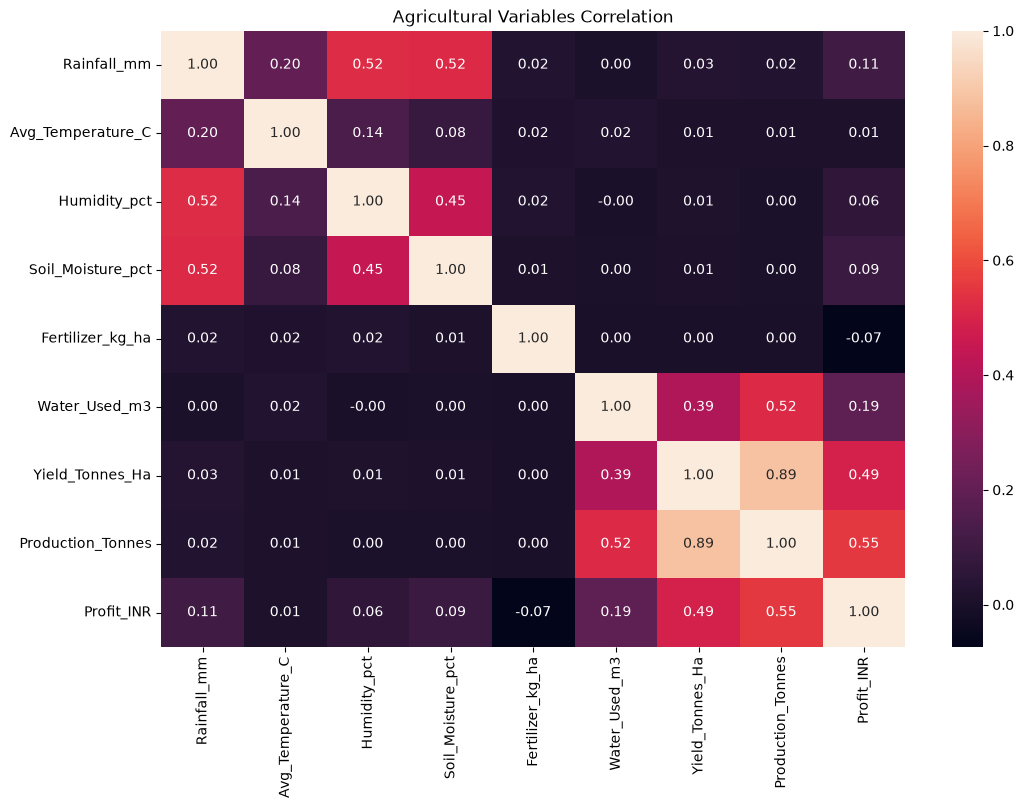

In [74]:
#3.2 Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Agricultural Variables Correlation")

plt.show()

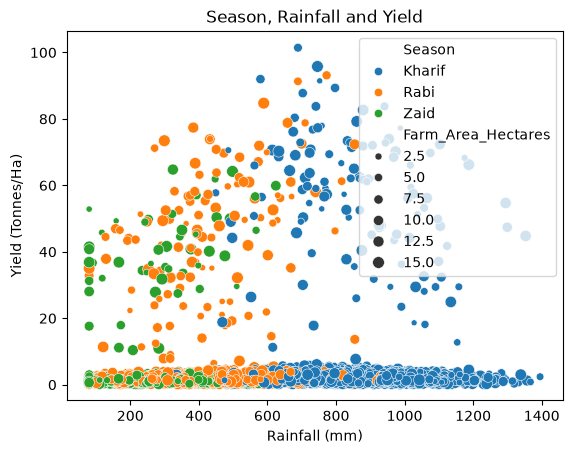

In [75]:
#3.3 Season + Rainfall + Yield
# Season, Rainfall and Yield together

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares"
)

plt.title("Season, Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

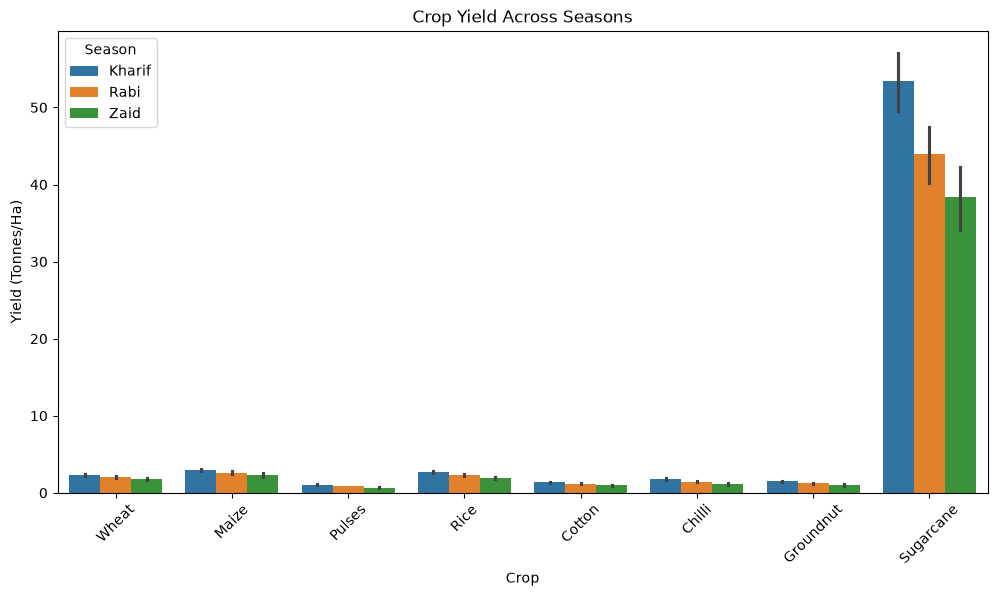

In [76]:
#3.4 Season + Crop + Yield
# Season, Crop and Yield

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.show()

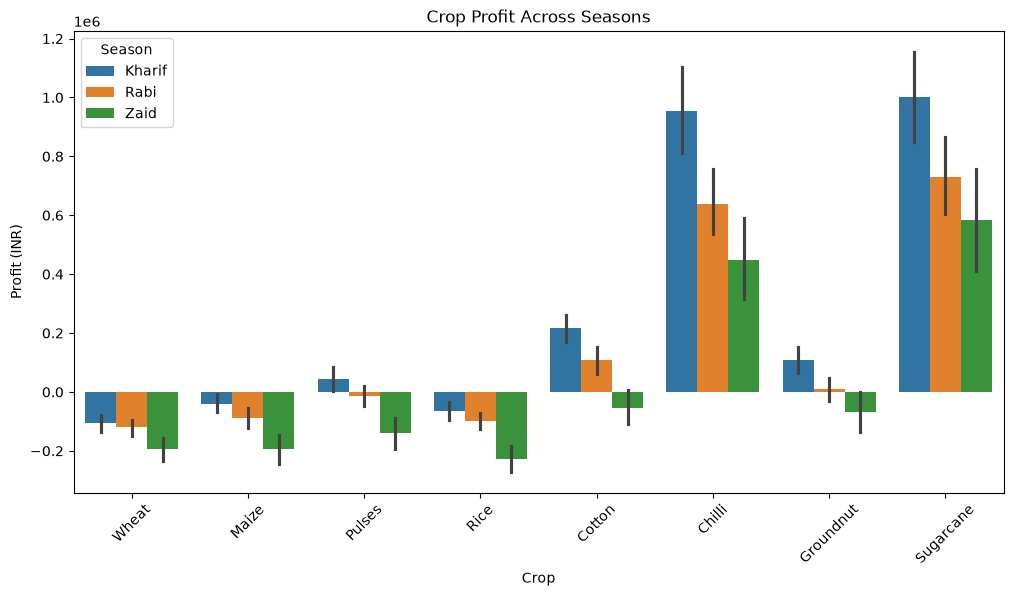

In [77]:
#3.5 Season + Profit + Crop
# Season, Crop and Profit

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Crop",
    y="Profit_INR",
    hue="Season"
)

plt.title("Crop Profit Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Profit (INR)")

plt.xticks(rotation=45)

plt.show()


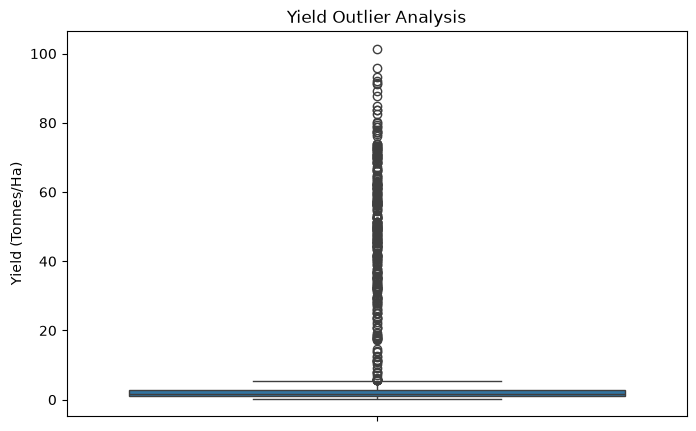

In [78]:
#4. OUTLIER ANALYSIS

#Outlier analysis identifies unusually high or low values.

#4.1 Yield Outliers
# ============================================================
# OUTLIER ANALYSIS
# Yield Outliers
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Outlier Analysis")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()


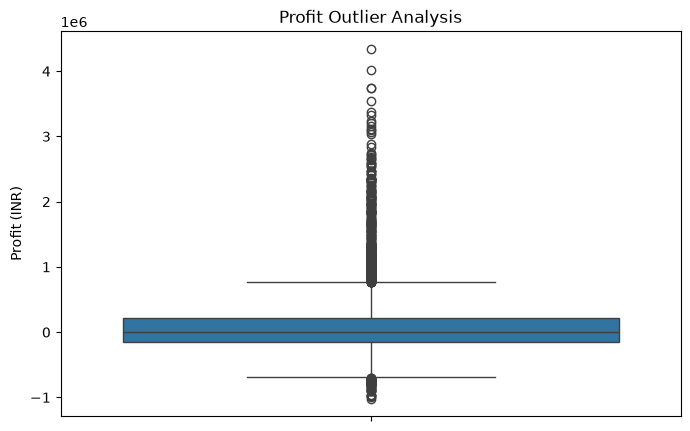

In [79]:
#4.2 Profit Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Profit_INR"
)

plt.title("Profit Outlier Analysis")
plt.ylabel("Profit (INR)")

plt.show()

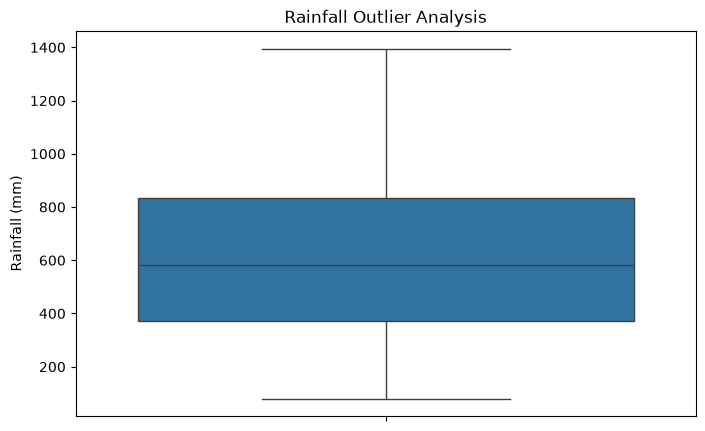

In [80]:
#4.3 Rainfall Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Rainfall_mm"
)

plt.title("Rainfall Outlier Analysis")
plt.ylabel("Rainfall (mm)")

plt.show()

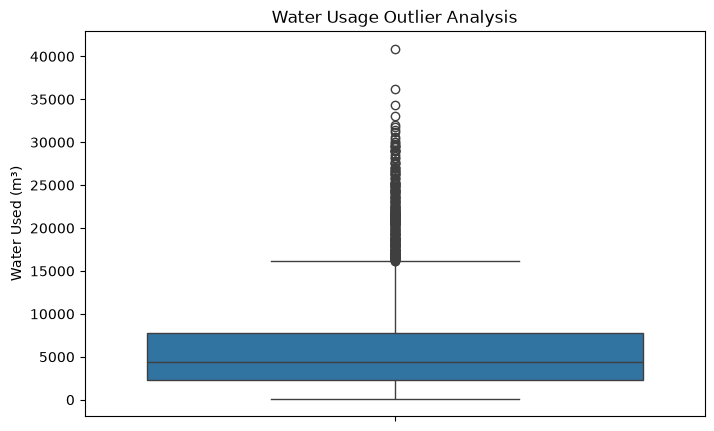

In [81]:
#4.4 Water Usage Outliers
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Water_Used_m3"
)

plt.title("Water Usage Outlier Analysis")
plt.ylabel("Water Used (m³)")

plt.show()

In [82]:
#5. FIND OUTLIERS USING IQR

#This is useful for explaining outlier analysis during your presentation.
# IQR method for Yield

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)

Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

Q1: 1.05
Q3: 2.84
IQR: 1.7899999999999998
Lower Limit: -1.6349999999999996
Upper Limit: 5.5249999999999995


In [83]:
#Display Yield Outliers
yield_outliers = df[
    (df["Yield_Tonnes_Ha"] < lower) |
    (df["Yield_Tonnes_Ha"] > upper)
]

yield_outliers

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,7.68,90.0,31.9,52.7,9.8,...,0.76,36.69,281.78,3682,480826,1037514,556688,13263,21.246,30.0
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,10.64,869.0,33.2,82.3,5.6,...,0.79,62.58,665.85,3651,755288,2431018,1675730,23608,28.204,58.8
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,9.29,353.9,30.6,46.8,9.1,...,0.90,33.55,311.68,3955,541528,1232694,691166,8213,37.950,31.2
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,2.46,629.3,23.5,47.5,8.9,...,0.83,49.52,121.82,3654,165909,445130,279221,2611,46.656,35.2
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,12.74,973.7,29.9,57.5,7.4,...,0.72,70.23,894.73,3671,856862,3284554,2427692,18596,48.114,51.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,SF13898,Karnataka,Rajkot,Sugarcane,Zaid,14.99,292.5,26.4,55.6,8.8,...,0.79,31.82,476.98,3365,898221,1605038,706817,29415,16.216,38.2
3940,SF13941,Madhya Pradesh,Nalgonda,Sugarcane,Zaid,2.11,398.4,31.1,37.8,8.8,...,1.00,35.88,75.71,3367,124124,254916,130792,4221,17.937,32.0
3966,SF13967,Maharashtra,Raichur,Sugarcane,Rabi,7.97,399.2,24.4,54.1,9.1,...,0.65,51.04,406.79,3199,560564,1301321,740757,19853,20.490,37.3
3981,SF13982,Andhra Pradesh,Guntur,Sugarcane,Kharif,3.13,1153.6,26.5,75.3,6.0,...,0.82,12.74,39.88,3442,203346,137267,-66079,4931,8.088,63.0


In [84]:
#6. OUTLIERS FOR PROFIT
# IQR method for Profit

Q1 = df["Profit_INR"].quantile(0.25)

Q3 = df["Profit_INR"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

profit_outliers = df[
    (df["Profit_INR"] < lower) |
    (df["Profit_INR"] > upper)
]

profit_outliers

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7
30,SF10031,Telangana,Nalgonda,Chilli,Rabi,11.96,284.2,24.1,62.1,7.0,...,0.66,1.51,18.06,102219,738746,1846075,1107329,4721,3.825,40.2
61,SF10062,Karnataka,Ludhiana,Cotton,Rabi,14.23,404.4,19.4,55.8,7.9,...,0.90,1.80,25.61,70385,815920,1802560,986640,9798,2.614,50.7
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,10.64,869.0,33.2,82.3,5.6,...,0.79,62.58,665.85,3651,755288,2431018,1675730,23608,28.204,58.8
78,SF10079,Madhya Pradesh,Nalgonda,Chilli,Rabi,10.00,288.6,23.8,61.1,6.9,...,0.90,2.18,21.80,106176,681239,2314637,1633398,6656,3.275,48.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3964,SF13965,Telangana,Nalgonda,Chilli,Kharif,10.59,661.5,31.0,76.3,7.7,...,0.92,2.41,25.52,100522,603318,2565321,1962003,3738,6.827,47.3
3967,SF13968,Tamil Nadu,Ludhiana,Maize,Kharif,12.79,590.4,31.5,53.6,5.9,...,0.86,0.66,8.44,15749,873885,132922,-740963,7779,1.085,43.9
3975,SF13976,Andhra Pradesh,Guntur,Chilli,Rabi,8.38,267.0,23.5,68.7,7.2,...,0.88,1.56,13.07,114449,587194,1495848,908654,3026,4.319,52.1
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,13.68,717.2,29.3,66.4,7.8,...,0.82,3.02,41.31,98175,844264,4055609,3211345,7219,5.722,49.6


In [85]:
# ============================================================
# REMOVING OUTLIERS USING IQR METHOD
# ============================================================

outlier_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Water_Used_m3"
]

df_clean = df.copy()

for col in outlier_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]

print("Original dataset shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original dataset shape: (4000, 28)
After removing outliers: (2965, 28)


In [86]:
# Number of removed rows

removed_rows = len(df) - len(df_clean)

print("Number of rows removed:", removed_rows)

Number of rows removed: 1035


In [87]:
# Use cleaned dataset for further analysis

df = df_clean.copy()

print("Final dataset shape:", df.shape)

Final dataset shape: (2965, 28)


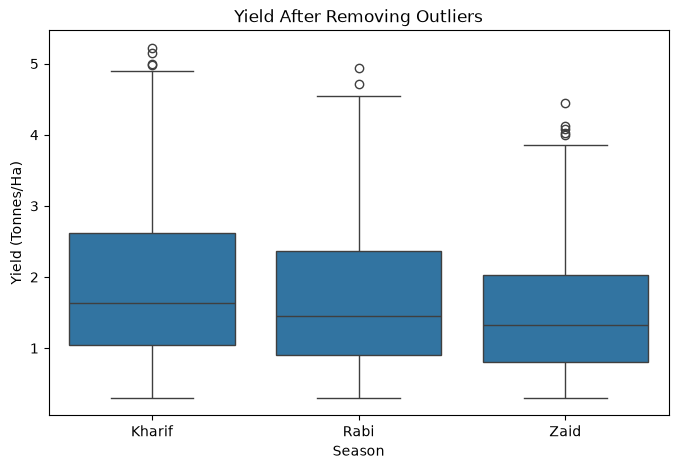

In [88]:
# Check yield after removing outliers

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield After Removing Outliers")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [89]:
# ============================================================
# MULTIVARIATE SEASONAL SUMMARY
# ============================================================

df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Water_Used_m3": "mean",
    "Fertilizer_kg_ha": "mean",
    "Profit_INR": "mean"
}).round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Fertilizer_kg_ha,Profit_INR
Season,,,,,,,
Kharif,1.88,12.54,856.51,28.45,4066.36,188.48,3048.08
Rabi,1.67,11.42,432.48,23.47,4155.28,185.57,-34233.90
Zaid,1.46,10.64,299.54,30.99,4493.73,182.30,-97097.26


In [90]:
# Final summary

final_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Water_Used_m3"
]].mean()

final_summary.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Rainfall_mm,Water_Used_m3
Season,,,,,
Kharif,1.88,12.54,3048.08,856.51,4066.36
Rabi,1.67,11.42,-34233.90,432.48,4155.28
Zaid,1.46,10.64,-97097.26,299.54,4493.73


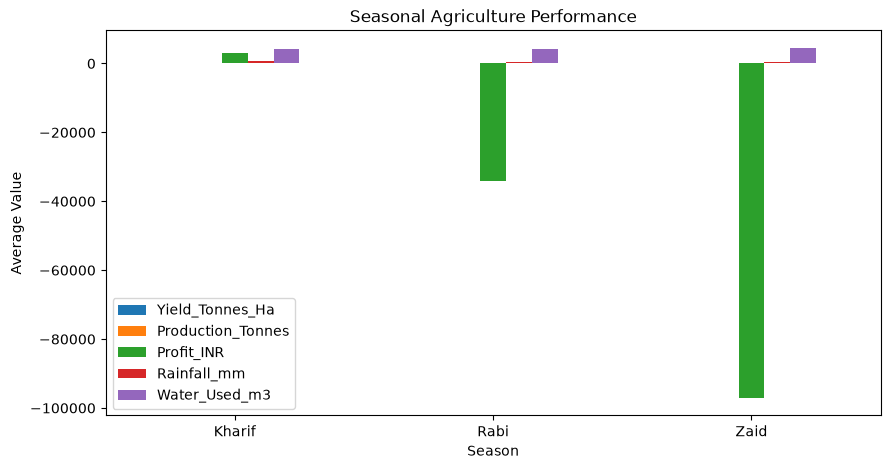

In [91]:
# Final Bar Plot

final_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Seasonal Agriculture Performance")
plt.xlabel("Season")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

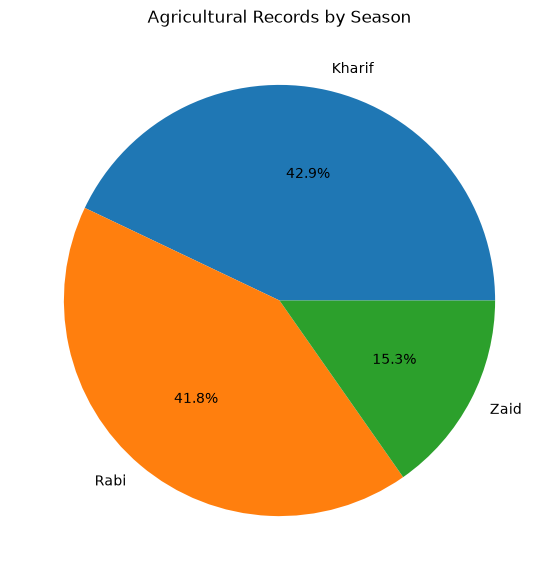

In [92]:
# Pie Chart - Season Distribution

season_count = df["Season"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    season_count,
    labels=season_count.index,
    autopct="%1.1f%%"
)

plt.title("Agricultural Records by Season")

plt.show()

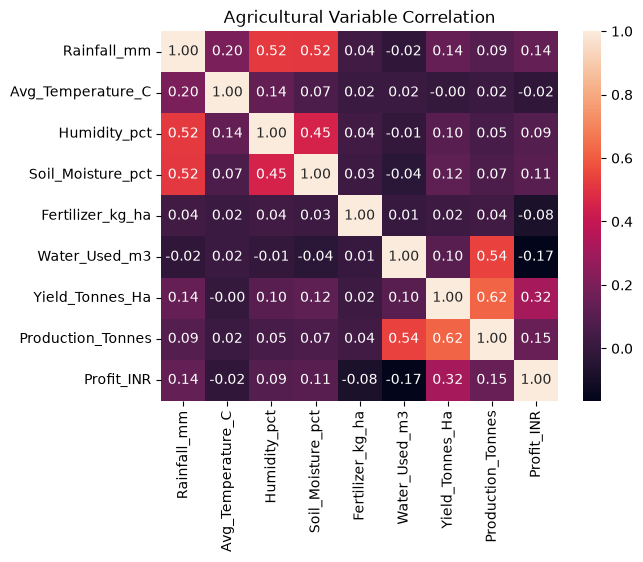

In [93]:
# Correlation Heatmap

correlation = df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Agricultural Variable Correlation")

plt.show()

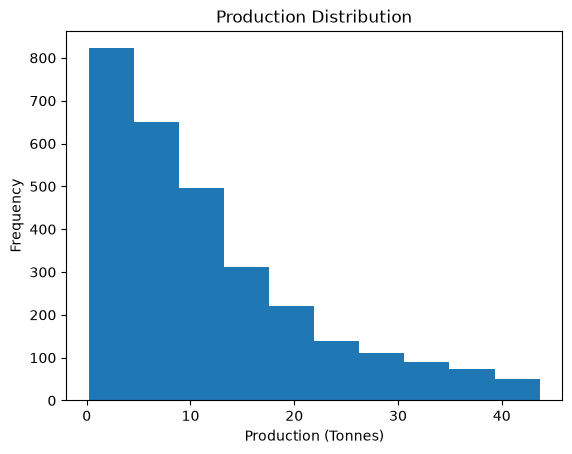

In [94]:
# Final Histogram - Production

plt.hist(
    df["Production_Tonnes"],
    bins=10
)

plt.title("Production Distribution")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Frequency")

plt.show()

In [95]:
# Final Seasonal Comparison

planning = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Water_Used_m3"
]].mean()

print(planning.round(2))

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Rainfall_mm  \
Season                                                                
Kharif             1.88              12.54     3048.08       856.51   
Rabi               1.67              11.42   -34233.90       432.48   
Zaid               1.46              10.64   -97097.26       299.54   

        Water_Used_m3  
Season                 
Kharif        4066.36  
Rabi          4155.28  
Zaid          4493.73  


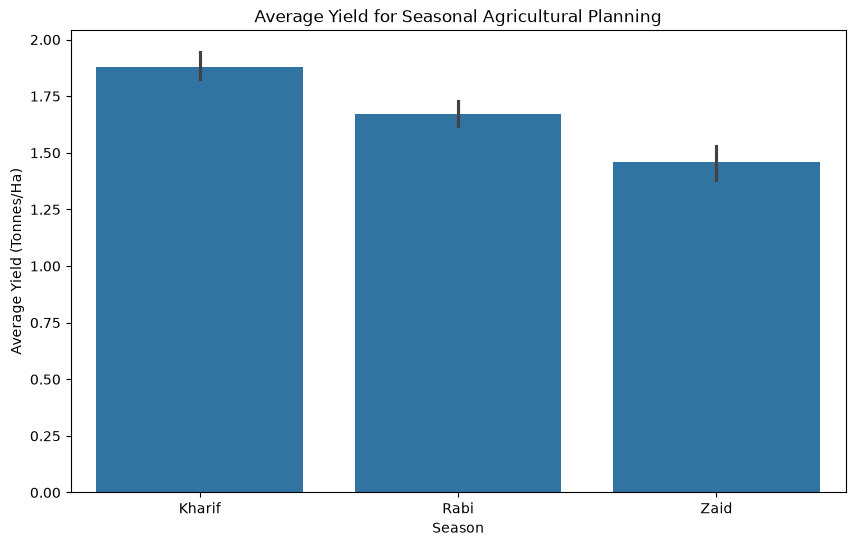

In [96]:
# Final Seasonal Performance Chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield for Seasonal Agricultural Planning")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()